# Advanced Artificial Intelligence Task 2
### Produce classification via pre-trained models across different architectures

- **CNN**:          EfficientNet_V2
- **TRANSFORMER**:   Swin
- **HYBRID**:       MaxVit
Details for the pre-trained weights can be found [here](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_v2_s.html#torchvision.models.efficientnet_v2_s).

Training metrics are logged to [Weights & Biases](https://wandb.ai). Before the first run: `wandb login` (one-time) to log into the shared workspace.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torchmetrics
import os
from torchvision.transforms import v2
from torchvision.transforms import v2 as T
from torchvision.models import get_model, get_weight
from torch.nn import CrossEntropyLoss
from torch.optim import SGD, Adam
from torchmetrics import Metric
import wandb
from tqdm import tqdm
from pathlib import Path
import datetime
import sys
import numpy as np
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import v2 as T
import random
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from safetensors.torch import save_file
import optuna
import platform

sys.path.append("..")
sys.path.append(".")
# from experiment_configs import task_2_config as experiments
from experiment_configs import task_2_config_final as experiments
from utils.dataset import ProduceDataset
from utils.mtl_model import MultiTaskClassifier
from utils.utils import seed_everything
from utils.mtlmix_up import MTLMixUp, _MTLBaseMixUpCutMix,  MTLCutMix
from utils.calibration import create_calibration_plots
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()
# Set workers based on platform
if sys.platform in ["linux", "darwin"]:
    # Linux, WSL or Mac
    print("Running on a Unix")
    WORKERS = int(os.cpu_count() * 0.75) 
else:
    sys.platform == "win32"
    # Native Windows - seemingly has sensitivity with workers.
    print("Running on Windows")
    WORKERS = int(os.cpu_count() * 0.20) 

Running on Windows


c:\Users\kxklm\AAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === DEFINE EXPERIMENT & DATASET HERE FOR SINGLE RUNS ===
EXP = experiments.EX6a_SWIN_FINETUNE_MTL
DATASET_PATH = "Fruit_And_Vegetable_Diseases_Dataset_no_identical_no_aug"

# Resolve EXP after papermill has injected overrides above.
valid_experiments = [
    name for name in dir(experiments)
    if isinstance(getattr(experiments, name), experiments.Experiment)
]
print(f"Selectable experiments:\n {valid_experiments}")

print(f"\nSelected: {EXP.display_name}")


Selectable experiments:
 ['EX1T_EFFICIENTNET_FINETUNE', 'EX1_EFFICIENTNET_FINETUNE', 'EX2T_SWIN_FINETUNE', 'EX2_SWIN_FINETUNE', 'EX3_MAXVIT_FINETUNE', 'EX4a_EFFICIENTNET_FINETUNE_MTL', 'EX4b_EFFICIENTNET_FINETUNE_MTL', 'EX4c_EFFICIENTNET_FINETUNE_MTL', 'EX5a_MAXVIT_FINETUNE_MTL', 'EX5b_MAXVIT_FINETUNE_MTL', 'EX5c_MAXVIT_FINETUNE_MTL', 'EX6a_SWIN_FINETUNE_MTL', 'EX6b_SWIN_FINETUNE_MTL', 'EX6c_SWIN_FINETUNE_MTL', 'EX7a_SWIN_MTL_FREEZE', 'EX7b_SWIN_MTL_SCRATCH', 'EX7c_SWIN_MTL_UNWEIGHTED', 'EX8a_SWIN_FINETUNE_MTL_AUG']

Selected: EX6a_SWIN_FINETUNE_MTL


In [3]:
# TRAINING PARAMETERS
SKIP_TRAIN = True
RECORD_WANDB = False
# Define primary dataset path and validate file count
PRODUCE_DATASET_PATH = Path("data") / DATASET_PATH
EXPECTED_FILES = 19392 
actual = sum(1 for p in PRODUCE_DATASET_PATH.rglob("*") if p.is_file())
assert actual == EXPECTED_FILES, f"Dataset drift: expected {EXPECTED_FILES} files, got {actual}"

# Seed for reproducability
# https://gist.github.com/ihoromi4/b681a9088f348942b01711f251e5f964
seed_everything(42)
gen = torch.Generator()
gen.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MTL WEIGHTS
# Task weighting follows a zero-sum logic to maintain loss scale consistency.
# Primary: Binary Health (Healthy/Rotten)
# Auxiliary: Multiclass Produce Type
# Unused when EXP.is_mtl is False (STL path skips the type head entirely).
TYPE_LOSS_WEIGHT = 1 - EXP.primary_task_weight
assert EXP.primary_task_weight + TYPE_LOSS_WEIGHT == 1

# Batch size of 32 for all experiemnts
# Change batch size and acc proportion as required for performance (in configs)
BATCH_SIZE = EXP.batch_size
ACCUMULATION_STEPS = EXP.acc_steps
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * ACCUMULATION_STEPS
assert EFFECTIVE_BATCH_SIZE == 32, ("Effective batch size must be 32 for training stability. "
                                    "Adjust BATCH_SIZE or GRADIENT_ACCUMULATION_STEPS accordingly.")
TEST_SPLIT = 0.8 
MAXIMUM_EPOCHS = 20 # Define maximum for early-stopping.
NUM_CLASSES = 2 # Healthy & Rotten
EARLY_STOPPING_PATIENCE = 5 # Defines how many non-improvement epochs will terminate run

# Test over-confidence
TEST_CONFIDENCE = True

# Extract required transformations for model image input (used by ProduceDataset)
pretrained_weights = get_weight(EXP.weight_string)
auto_transforms = pretrained_weights.transforms()



Loaded 19392 images total

Class Breakdown
HEALTHY (0)         9330
ROTTEN (1)          10062


Type Breakdown
APPLE               2641
BANANA              2108
BELLPEPPER          1062
CARROT              1015
CUCUMBER            870
GRAPE               400
GUAVA               400
JUJUBE              400
MANGO               3160
ORANGE              2286
POMEGRANATE         399
POTATO              1008
STRAWBERRY          2523
TOMATO              1120
Sample: 0 Rotten
Sample: 1 Healthy
Sample: 2 Healthy
Sample: 3 Rotten
Sample: 4 Rotten


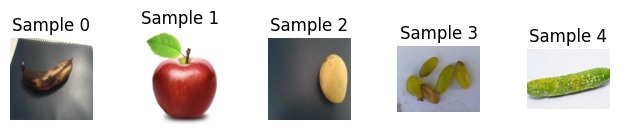

In [4]:
# Initialize the dataset and assign labels based on folder structure
produce_dataset = ProduceDataset(dataset_root_dir=PRODUCE_DATASET_PATH,
                                  transform=auto_transforms)
produce_dataset.print_class_balance()
produce_dataset.display_examples(num_samples=5, show_transformed=False)


In [5]:
# Stratify by produce category + label so the split preserves per-category class balance
# Construct list of of (<category>,<label>) (e.g. (0, 1), (0, 1), (1, 1),...)
stratify_keys = list(zip(produce_dataset.produce_type_lbls,
                         produce_dataset.health_lbls))

train_index, val_index = train_test_split(
    range(len(produce_dataset)), # Split the indices (0 - 29291), not the data itself
    test_size=1 - TEST_SPLIT,
    stratify=stratify_keys,
    random_state=42,
)

train_dataset = torch.utils.data.Subset(produce_dataset, train_index)
val_dataset   = torch.utils.data.Subset(produce_dataset, val_index)

# Assert that the datasets are balanced across produce and health labels
full  = Counter(stratify_keys)
train = Counter(stratify_keys[i] for i in train_index)
val   = Counter(stratify_keys[i] for i in val_index)
TOLERANCE = 0.005
for k in sorted(full):
    full_pct = full[k]/len(stratify_keys)
    train_pct = train[k]/len(train_index)
    val_pct = val[k]/len(val_index)
    status = "GOOD" if abs(train_pct - full_pct) < TOLERANCE and abs(val_pct - full_pct) < TOLERANCE else "BAD"
    print(f"{str(k):<10} full {full_pct:.3f}  train {train_pct:.3f}  val {val_pct:.3f}  {status}")
    assert abs(train_pct - full_pct) < TOLERANCE and abs(val_pct - full_pct) < TOLERANCE, \
        f"Stratification skewed for {k}"

(0, 0)     full 0.068  train 0.068  val 0.068  GOOD
(0, 1)     full 0.069  train 0.069  val 0.069  GOOD
(1, 0)     full 0.039  train 0.039  val 0.039  GOOD
(1, 1)     full 0.070  train 0.070  val 0.070  GOOD
(2, 0)     full 0.028  train 0.028  val 0.028  GOOD
(2, 1)     full 0.026  train 0.026  val 0.026  GOOD
(3, 0)     full 0.028  train 0.028  val 0.028  GOOD
(3, 1)     full 0.024  train 0.024  val 0.024  GOOD
(4, 0)     full 0.022  train 0.022  val 0.022  GOOD
(4, 1)     full 0.022  train 0.022  val 0.022  GOOD
(5, 0)     full 0.010  train 0.010  val 0.010  GOOD
(5, 1)     full 0.010  train 0.010  val 0.010  GOOD
(6, 0)     full 0.010  train 0.010  val 0.010  GOOD
(6, 1)     full 0.010  train 0.010  val 0.010  GOOD
(7, 0)     full 0.010  train 0.010  val 0.010  GOOD
(7, 1)     full 0.010  train 0.010  val 0.010  GOOD
(8, 0)     full 0.074  train 0.074  val 0.074  GOOD
(8, 1)     full 0.089  train 0.089  val 0.089  GOOD
(9, 0)     full 0.058  train 0.058  val 0.058  GOOD
(9, 1)     f

In [6]:
# Class-weighted loss to counteract Healthy/Rotten & produce imbalances (computed on training set only)
train_health_labels = [produce_dataset.health_lbls[i] for i in train_index]
train_type_labels = [produce_dataset.produce_type_lbls[i] for i in train_index]

def weighted_cross_entropy(labels, indices):
    y = [labels[i] for i in indices]
    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
    return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float).to(device)), weights

if EXP.class_weighted:
    health_criterion, health_weights = weighted_cross_entropy(produce_dataset.health_lbls, train_index)
    type_criterion,   type_weights   = weighted_cross_entropy(produce_dataset.produce_type_lbls, train_index)
    print(f"Health class weights: {health_weights}")
    print(f"Type class weights:   {type_weights}")
else:
    health_criterion = nn.CrossEntropyLoss()
    type_criterion   = nn.CrossEntropyLoss()
    print("Unweighted CE (class_weighted=False)")


Health class weights: [1.0391881  0.96366008]
Type class weights:   [0.52440673 0.65721912 1.30361345 1.36461999 1.59205665 3.46272321
 3.46272321 3.46272321 0.43831939 0.60583457 3.47357815 1.37477845
 0.54909387 1.23668686]


C:\Users\kxklm\AppData\Local\Temp\ipykernel_33544\720454404.py:8: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float).to(device)), weights


In [7]:
# Initialise dataloaders - https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/
# Shuffle training data for better generalization
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=WORKERS, pin_memory=True, generator=gen,
                          persistent_workers=True) 
# No need to shuffle validation data 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=WORKERS, pin_memory=True,
                        persistent_workers=True) 



print(f"\nTraining size: {len(train_dataset)}  |  Validation size: {len(val_dataset)}")


Training size: 15513  |  Validation size: 3879


In [8]:
# Define train/validation functions
# https://medium.com/@ebimsv/mastering-cnns-in-pytorch-week-2-building-and-training-custom-and-pretrained-cnns-for-image-f040572c73c1




class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0
        self.count = 0

    def update(self, value, n=1):
        self.sum += value * n
        self.count += n

    @property
    def avg(self):
        return self.sum / self.count if self.count > 0 else 0

def train_one_epoch(model: nn.Module, dataloader: DataLoader,
                    health_criterion: CrossEntropyLoss, type_criterion: CrossEntropyLoss,
                    optimizer: SGD | Adam, device: torch.device, epoch: int,
                    health_accuracy: Metric, type_accuracy: Metric, is_mtl: bool,
                    augment=None ) -> tuple:
    model.train()
    loss_meter = AverageMeter()
    health_loss_meter = AverageMeter()
    type_loss_meter = AverageMeter()
    health_accuracy.reset()
    type_accuracy.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Training]", leave=False)

    # zero gradients once at the start of the epoch
    optimizer.zero_grad()

    # Iterate over batches (image, health label, type label)
    for id, (X_batch, y_health, y_type) in enumerate(progress_bar):
        X_batch = X_batch.to(device)
        y_health = y_health.to(device)
        if is_mtl:
            y_type = y_type.to(device)
        if augment is not None:
            # Detect MTL aug: direct instance, or a RandomChoice that contains at least one MTL
            # transform. augment.transforms is a ModuleList, not a single transform — must iterate.
            is_mtl_aug = isinstance(augment, _MTLBaseMixUpCutMix) or (
                isinstance(augment, v2.RandomChoice)
                and any(isinstance(t, _MTLBaseMixUpCutMix) for t in augment.transforms)
            )

            if is_mtl_aug:
                # Pass all three to our custom classes
                X_batch, y_health, y_type = augment(X_batch, y_health, y_type)
            else:
                # Standard traditional augmentation (RandAugment, etc.)
                X_batch = augment(X_batch)
                X_batch = X_batch.clamp(-3.0, 3.0)
        # Forward + loss: MTL returns (health, type); STL returns health only
        if is_mtl:
            y_type = y_type.to(device)
            health_output, type_output = model(X_batch)
            loss_health = health_criterion(health_output, y_health)
            loss_type = type_criterion(type_output, y_type)
            loss = (EXP.primary_task_weight * loss_health
                + TYPE_LOSS_WEIGHT * loss_type)
        else:
            health_output = model(X_batch)
            loss_health = health_criterion(health_output, y_health)
            loss = loss_health

        # Scale loss by accumulation steps so gradients are averaged, not summed
        (loss / ACCUMULATION_STEPS).backward()

        # Only step the optimizer every ACCUMULATION_STEPS batches (or on the last batch)
        if (id + 1) % ACCUMULATION_STEPS == 0 or (id + 1) == len(dataloader):
            optimizer.step()
            optimizer.zero_grad()

        # Update metrics (use unscaled loss for logging).
        # MixUp/CutMix returns soft one-hot labels ([B, C]); torchmetrics.Accuracy
        # needs hard indices. Collapse via argmax — training accuracy under mix is
        # only a rough monitoring signal anyway.
        loss_meter.update(loss.item(), X_batch.size(0))
        health_loss_meter.update(loss_health.item(), X_batch.size(0))
        y_health_hard = y_health.argmax(dim=1) if y_health.ndim > 1 else y_health
        health_accuracy.update(health_output.argmax(dim=1), y_health_hard)
        if is_mtl:
            y_type_hard = y_type.argmax(dim=1) if y_type.ndim > 1 else y_type
            type_loss_meter.update(loss_type.item(), X_batch.size(0))
            type_accuracy.update(type_output.argmax(dim=1), y_type_hard)
        if id % 50 == 0:
            postfix = {"loss": loss_meter.avg, "health_acc": health_accuracy.compute().item()}
            if is_mtl:
                postfix["type_acc"] = type_accuracy.compute().item()
            progress_bar.set_postfix(**postfix)

    avg_loss = loss_meter.avg
    avg_health_loss = health_loss_meter.avg
    avg_type_loss = type_loss_meter.avg if is_mtl else 0.0
    avg_health_acc = health_accuracy.compute().item()
    avg_type_acc = type_accuracy.compute().item() if is_mtl else 0.0

    return avg_loss, avg_health_loss, avg_type_loss, avg_health_acc, avg_type_acc

def validate(model: nn.Module, dataloader: DataLoader, health_criterion: CrossEntropyLoss,
             type_criterion: CrossEntropyLoss, device: torch.device, epoch: int,
             health_accuracy: Metric, type_accuracy: Metric, is_mtl: bool) -> tuple:
    model.eval()
    loss_meter = AverageMeter()
    health_loss_meter = AverageMeter()
    type_loss_meter = AverageMeter()
    health_accuracy.reset()
    type_accuracy.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Validation]", leave=False)

    with torch.no_grad():
        for id, (X_batch, y_health, y_type) in enumerate(progress_bar):
            X_batch = X_batch.to(device)
            y_health = y_health.to(device)

            if is_mtl:
                y_type = y_type.to(device)
                health_output, type_output = model(X_batch)
                loss_health = health_criterion(health_output, y_health)
                loss_type = type_criterion(type_output, y_type)
                loss = (EXP.primary_task_weight * loss_health
                    + TYPE_LOSS_WEIGHT * loss_type)
            else:
                health_output = model(X_batch)
                loss_health = health_criterion(health_output, y_health)
                loss = loss_health

            loss_meter.update(loss.item(), X_batch.size(0))
            health_loss_meter.update(loss_health.item(), X_batch.size(0))
            health_accuracy.update(health_output.argmax(dim=1), y_health)
            if is_mtl:
                type_loss_meter.update(loss_type.item(), X_batch.size(0))
                type_accuracy.update(type_output.argmax(dim=1), y_type)

            if id % 50 == 0:
                postfix = {"loss": loss_meter.avg, "health_acc": health_accuracy.compute().item()}
                if is_mtl:
                    postfix["type_acc"] = type_accuracy.compute().item()
                progress_bar.set_postfix(**postfix)

    avg_loss = loss_meter.avg
    avg_health_loss = health_loss_meter.avg
    avg_type_loss = type_loss_meter.avg if is_mtl else 0.0
    avg_health_acc = health_accuracy.compute().item()
    avg_type_acc = type_accuracy.compute().item() if is_mtl else 0.0

    return avg_loss, avg_health_loss, avg_type_loss, avg_health_acc, avg_type_acc


In [9]:
# TRAIN/VALIDATION LOOP
timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
model_save_name = f"{EXP.display_name }_{timestamp}"


In [10]:
# OPTUMA HYPERPARAMETER TUNING


SWEEP_RESULTS_DIR = Path("runs") / "sweeps"
SWEEP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sweep_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
SWEEP_LOG_PATH = SWEEP_RESULTS_DIR / f"{EXP.display_name}_sweep_{sweep_timestamp}.txt"
SWEEP_DB_PATH  = SWEEP_RESULTS_DIR / f"{EXP.display_name}_sweep_{sweep_timestamp}.db"

def _log(msg: str):
    print(msg)
    with open(SWEEP_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(msg + "\n")

_log(f"Sweep start: {EXP.display_name} | dataset={DATASET_PATH} | {sweep_timestamp}")

# Image size driven by pretrained weights (Swin 224, EfficientNetV2-S 384, etc.)
TRIAL_IMG_SIZE = pretrained_weights.transforms().crop_size[0]

# Cache weight object once — avoid re-fetching per trial
CACHED_WEIGHTS = get_weight(EXP.weight_string) if EXP.pretrained else None

def objective(trial, mix=True):
    # Per-trial seed so augmentation/shuffle RNG varies between trials
    torch.manual_seed(42 + trial.number)
    np.random.seed(42 + trial.number)

    if mix:
        # Start at 0.1 to prevent PyTorch Beta distribution crash at alpha=0
        mixup_alpha = trial.suggest_float("mixup_alpha", 0.0, 1.0)
        cutmix_alpha = trial.suggest_float("cutmix_alpha", 0.0, 1.0)
        
        # Use our custom Multi-Task classes
        cutmix = MTLCutMix(
            alpha=cutmix_alpha, 
            num_health_classes=NUM_CLASSES, 
            num_type_classes=produce_dataset.num_produce_types
        )
        mixup = MTLMixUp(
            alpha=mixup_alpha, 
            num_health_classes=NUM_CLASSES, 
            num_type_classes=produce_dataset.num_produce_types
        )
        
        # Wrap them in v2.RandomChoice so it picks one per batch
        trial_augment = v2.RandomChoice([cutmix, mixup])
        
        _log(f"\n{'='*60}")
        _log(f"Trial {trial.number}: MIXUP/CUTMIX | mix_a={mixup_alpha:.2f}, cut_a={cutmix_alpha:.2f}")
        _log(f"{'='*60}")
    else:
        num_ops    = trial.suggest_int("num_ops", 1, 2, 3)
        magnitude  = trial.suggest_int("magnitude", 5, 7, 12)
        crop_scale = trial.suggest_categorical("crop_scale", [1.0, 0.85, 0.7])   # relative to preprocessed crop, not raw image
        v_flip_p   = trial.suggest_categorical("v_flip_p", [0.0, 0.5])
        blur_p     = trial.suggest_categorical("blur_p", [0.0, 0.25])
        erase_p    = trial.suggest_categorical("erase_p", [0.0, 0.25])

        _log(f"\n{'='*60}")
        _log(f"Trial {trial.number}: num_ops={num_ops}, magnitude={magnitude}, "
            f"crop_scale={crop_scale}, v_flip_p={v_flip_p}, blur_p={blur_p}, erase_p={erase_p}")
        _log(f"{'='*60}")

        ops = [T.RandomHorizontalFlip()]
        if v_flip_p > 0:
            ops.append(T.RandomVerticalFlip(p=v_flip_p))
        if crop_scale < 1.0:
            ops.append(T.RandomResizedCrop(TRIAL_IMG_SIZE, scale=(crop_scale, 1.0), antialias=True))
        ops.append(T.RandAugment(num_ops=num_ops, magnitude=magnitude))
        if blur_p > 0:
            ops.append(T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=blur_p))
        if erase_p > 0:
            ops.append(T.RandomErasing(p=erase_p))
        trial_augment = T.Compose(ops)
    PRETRAINED_MODEL = get_model(EXP.architecture, weights=CACHED_WEIGHTS)
    if not EXP.pretrained:
        _log(f"Random-init: skipping {EXP.weight_string}")
    if EXP.training.transfer_type == "FREEZE":
    # Freeze backbone if enabled; gradients are enabled by default for new layers
        for parameters in PRETRAINED_MODEL.parameters():
            # Do not compute backbone gradients (i.e., freeze weights)
            parameters.requires_grad = False

    if EXP.is_mtl:
        trial_model = MultiTaskClassifier(PRETRAINED_MODEL, num_produce_classes=produce_dataset.num_produce_types)
    else:
        # STL: Replace final layer with binary classifier (Healthy/Rotten)
        head_attr = "classifier" if hasattr(PRETRAINED_MODEL, "classifier") else "head"
        head = getattr(PRETRAINED_MODEL, head_attr)
        # Per-arch head replacement: EfficientNet/MaxViT expose .classifier (Sequential => Linear);
        if isinstance(head, nn.Sequential):
            head[-1] = nn.Linear(head[-1].in_features, NUM_CLASSES)
        # Swin exposes .head (single Linear).
        elif isinstance(head, nn.Linear):
            setattr(PRETRAINED_MODEL, head_attr, nn.Linear(head.in_features, NUM_CLASSES))
        else:
            raise ValueError(f"Unsupported STL classification_head: {type(head).__name__}")
        trial_model = PRETRAINED_MODEL
    trial_model = trial_model.to(device)

    # Extract parameters based on transfer learning method
    if EXP.training.transfer_type == "FREEZE":
        # Full backbone freeze
        trainable_params = [parameter for parameter in trial_model.parameters()
                            if parameter.requires_grad]
    else:
        # Freeze none
        _log(f"FINETUNE: unfroze all parameters of {EXP.architecture}")
        trainable_params = trial_model.parameters()

    trial_optimizer = optim.AdamW(trainable_params, lr=EXP.training.learning_rate, weight_decay=0.01)

    TRIAL_EPOCHS  = 4  # short run — enough signal for aug ranking without full training cost
    WARM_UP_EPOCHS = 1
    # Linearly warm up from 0 to LR to training lr over WARMUP_EPOCHS
    warmup = torch.optim.lr_scheduler.LinearLR(
        trial_optimizer, start_factor=0.01, total_iters=WARM_UP_EPOCHS)
    # Cosine decay from base LR to 0 across remaining trial epochs
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        trial_optimizer, T_max=TRIAL_EPOCHS - WARM_UP_EPOCHS)
    # Define a sequential scheduler that first applies warmup, then cosine decay
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        trial_optimizer, schedulers=[warmup, cosine], milestones=[WARM_UP_EPOCHS])

    train_health_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)
    train_type_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=produce_dataset.num_produce_types).to(device)
    val_health_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)
    val_type_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=produce_dataset.num_produce_types).to(device)

    for epoch in range(TRIAL_EPOCHS):
        (train_loss, train_health_loss, train_type_loss,
         train_health_acc, train_type_acc) = train_one_epoch(
            trial_model, train_loader, health_criterion, type_criterion,
            trial_optimizer, device, epoch, train_health_accuracy,
            train_type_accuracy, EXP.is_mtl,
            trial_augment)

        (val_loss, val_health_loss, val_type_loss,
         val_health_acc, val_type_acc) = validate(
            trial_model, val_loader, health_criterion, type_criterion,
            device, epoch, val_health_accuracy, val_type_accuracy, EXP.is_mtl)

        lr_scheduler.step()

        _log(f"  [Trial {trial.number}] epoch {epoch+1}/{TRIAL_EPOCHS}: "
             f"train_loss={train_health_loss:.4f} train_acc={train_health_acc:.4f} | "
             f"val_loss={val_health_loss:.4f} val_acc={val_health_acc:.4f}")
        # Pruning — stop unpromising trials early
        trial.report(val_health_loss, epoch)
        if trial.should_prune():
            _log(f"  >>> Trial {trial.number} pruned at epoch {epoch+1}")
            del trial_model, trial_optimizer
            torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()

    # Rank trials by final-epoch val loss (convergence), not by lucky minima.
    peak_mb = torch.cuda.max_memory_allocated() / 1e6
    torch.cuda.reset_peak_memory_stats()
    _log(f"  >>> Trial {trial.number} finished: val_loss={val_health_loss:.4f} | peak_mem_MB={peak_mb:.0f}")
    del trial_model, trial_optimizer
    torch.cuda.empty_cache()
    return val_health_loss


def log_best(study, trial):
    try:
        best = study.best_trial
        _log(f"  [Best so far: trial {best.number} -> "
             f"val_loss={best.value:.4f}, params={best.params}]")
    except ValueError:
        # No completed trial yet (all pruned, or first not finished)
        pass


# SQLite-backed study: survives kernel restarts. Re-running this cell with the same
# sweep_timestamp resumes; otherwise a fresh db is created for each run.
study = optuna.create_study(
    storage=f"sqlite:///{SWEEP_DB_PATH}",
    study_name=EXP.display_name,
    direction="minimize",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    sampler=optuna.samplers.TPESampler(seed=42),
)
# n_trials set high; timeout is the real stop criterion for the overnight run.
SWEEP_TIMEOUT_SEC = 4 * 3600  # 7h target; clamps between 6-8h depending on trial speed
study.optimize(objective, n_trials=20, timeout=SWEEP_TIMEOUT_SEC,
               callbacks=[log_best], show_progress_bar=True)

_log("\n" + "="*60)
_log("Best trial:")
_log(f"  Val loss: {study.best_trial.value:.4f}")
_log(f"  Params:   {study.best_trial.params}")
_log("="*60)

# Persist full trial table as CSV alongside the .txt log
trials_df = study.trials_dataframe()
csv_path = SWEEP_RESULTS_DIR / f"{EXP.display_name}_sweep_{sweep_timestamp}.csv"
trials_df.to_csv(csv_path, index=False)

# Parameter importance (variance decomposition across completed trials)
try:
    importances = optuna.importance.get_param_importances(study)
    _log("Param importance:")
    for k, v in importances.items():
        _log(f"  {k}: {v:.4f}")
except Exception as e:
    _log(f"Importance computation skipped: {e}")

_log(f"Saved trials table: {csv_path}")
_log(f"Saved log:          {SWEEP_LOG_PATH}")
_log(f"Saved study db:     {SWEEP_DB_PATH}")


Sweep start: EX6a_SWIN_FINETUNE_MTL | dataset=Fruit_And_Vegetable_Diseases_Dataset_no_identical_no_aug | 20260423_182858


[I 2026-04-23 18:28:58,391] A new study created in RDB with name: EX6a_SWIN_FINETUNE_MTL
  0%|          | 0/20 [00:00<?, ?it/s]


Trial 0: MIXUP/CUTMIX | mix_a=0.37, cut_a=0.95
[MTL] Detected head attr: '.head'  arch=SwinTransformer
[MTL] Original head:
Linear(in_features=768, out_features=1000, bias=True)
[MTL] Backbone+neck output shape: (1, 768)  (expected (1, 768))
FINETUNE: unfroze all parameters of swin_s


  [Trial 0] epoch 1/4: train_loss=0.7277 train_acc=0.5132 | val_loss=0.6993 val_acc=0.5228


  [Trial 0] epoch 2/4: train_loss=0.4212 train_acc=0.8506 | val_loss=0.0922 val_acc=0.9719


...

  [Trial 19] epoch 1/4: train_loss=0.6781 train_acc=0.5768 | val_loss=0.6394 val_acc=0.6499


  [Trial 19] epoch 2/4: train_loss=0.4292 train_acc=0.8537 | val_loss=0.0875 val_acc=0.9794


  [Trial 19] epoch 3/4: train_loss=0.3394 train_acc=0.9163 | val_loss=0.0620 val_acc=0.9850


Best trial: 11. Best value: 0.0264888: 100%|██████████| 20/20 [2:29:37<00:00, 448.89s/it, 8977.81/14400 seconds]


  [Trial 19] epoch 4/4: train_loss=0.3226 train_acc=0.9220 | val_loss=0.0529 val_acc=0.9876
  >>> Trial 19 pruned at epoch 4
[I 2026-04-23 20:58:36,193] Trial 19 pruned. 
  [Best so far: trial 11 -> val_loss=0.0265, params={'mixup_alpha': 0.007547319316293211, 'cutmix_alpha': 0.025610294628699154}]

Best trial:
  Val loss: 0.0265
  Params:   {'mixup_alpha': 0.007547319316293211, 'cutmix_alpha': 0.025610294628699154}
Param importance:
  mixup_alpha: 0.9635
  cutmix_alpha: 0.0365
Saved trials table: runs\sweeps\EX6a_SWIN_FINETUNE_MTL_sweep_20260423_182858.csv
Saved log:          runs\sweeps\EX6a_SWIN_FINETUNE_MTL_sweep_20260423_182858.txt
Saved study db:     runs\sweeps\EX6a_SWIN_FINETUNE_MTL_sweep_20260423_182858.db
